In [4]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings

In [5]:
# Suppress specific MatplotlibDeprecationWarning from the mentioned module
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning, module="scvelo.plotting.utils")

In [3]:
# Read input file
adata = scanpy.read_h5ad("/scratch/lema/m26_losu/splice_counts_mm10.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day'
    var: 'ensemble_ids', 'gene_symbol'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


In [24]:
# Define arguments
args = sdevelo.Config()
args.vis_key = "X_fdl"
args.vis_type_col = 'day'
args.scv_n_jobs = 20

In [ ]:
# Train SDEvelo model
model = sdevelo.SDENN(args, adata)
adata = model.train(100)

cpu
Filtered out 35658 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
Using scVelo version 0.3.3


/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
5000
Epoch: 0, Loss: 0.834, alpha: 12.85, beta: 11.22, gamma: 1.13, s1: 0.010, s2: 0.012,  t_m: 0.674,  u_shift: 0.000,  s_shift: -0.012
Epoch: 50, Loss: 0.625, alpha: 3.30, beta: 6.76, gamma: 0.01, s1: 0.010, s2: 0.010,  t_m: 0.861,  u_shift: 0.000,  s_shift: -0.090


In [15]:
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time'
    var: 'ensemble_ids', 'gene_symbol', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'sample_colors', 'log1p', 'pca', 'neighbors'
    obsm: 'X_fdl', 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'sde_velocity', 'pred_u', 'pred_s'
    obsp: 'distances', 'connectivities'


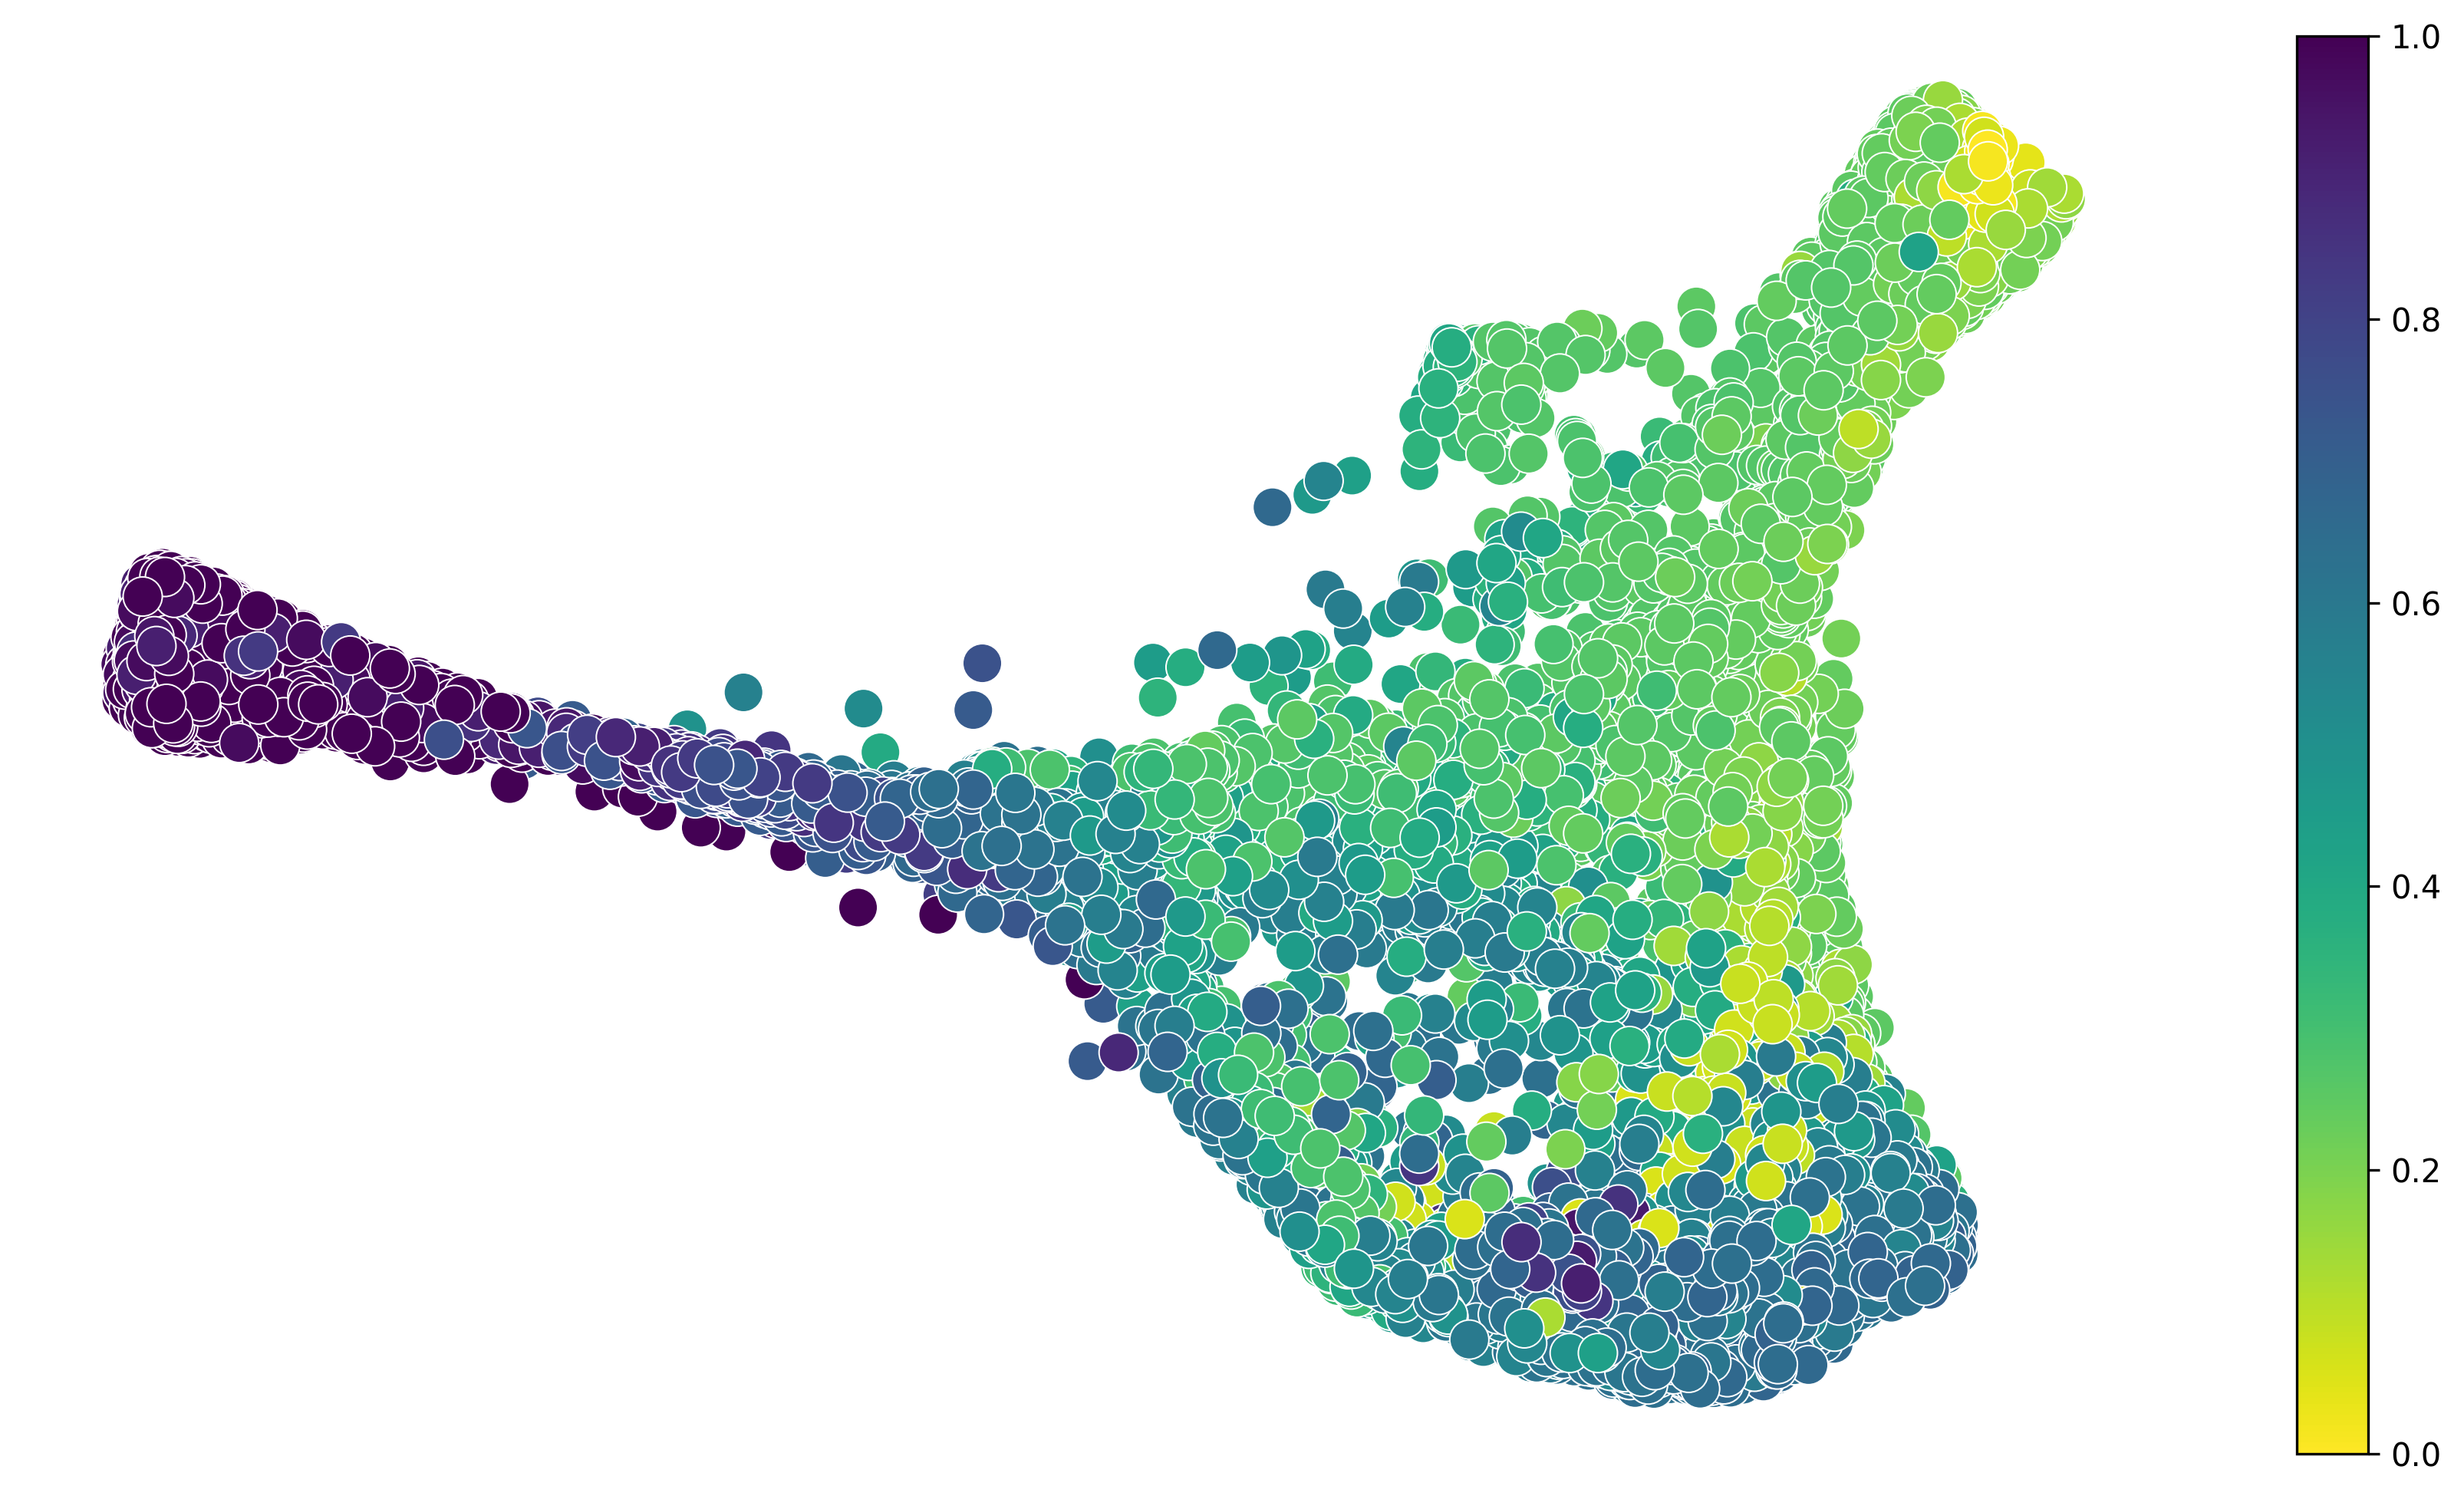

In [14]:
sdevelo.plot_latent_time(adata, args)

In [17]:
# Velocity cosine correlations
scvelo.tl.velocity_graph(adata, vkey="sde_velocity", n_jobs=16)

computing velocity graph (using 16/64 cores)


  0%|          | 0/12791 [00:00<?, ?cells/s]

/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=302052) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:17) --> added 
    'sde_velocity_graph', sparse matrix with cosine correlations (adata.uns)


/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/

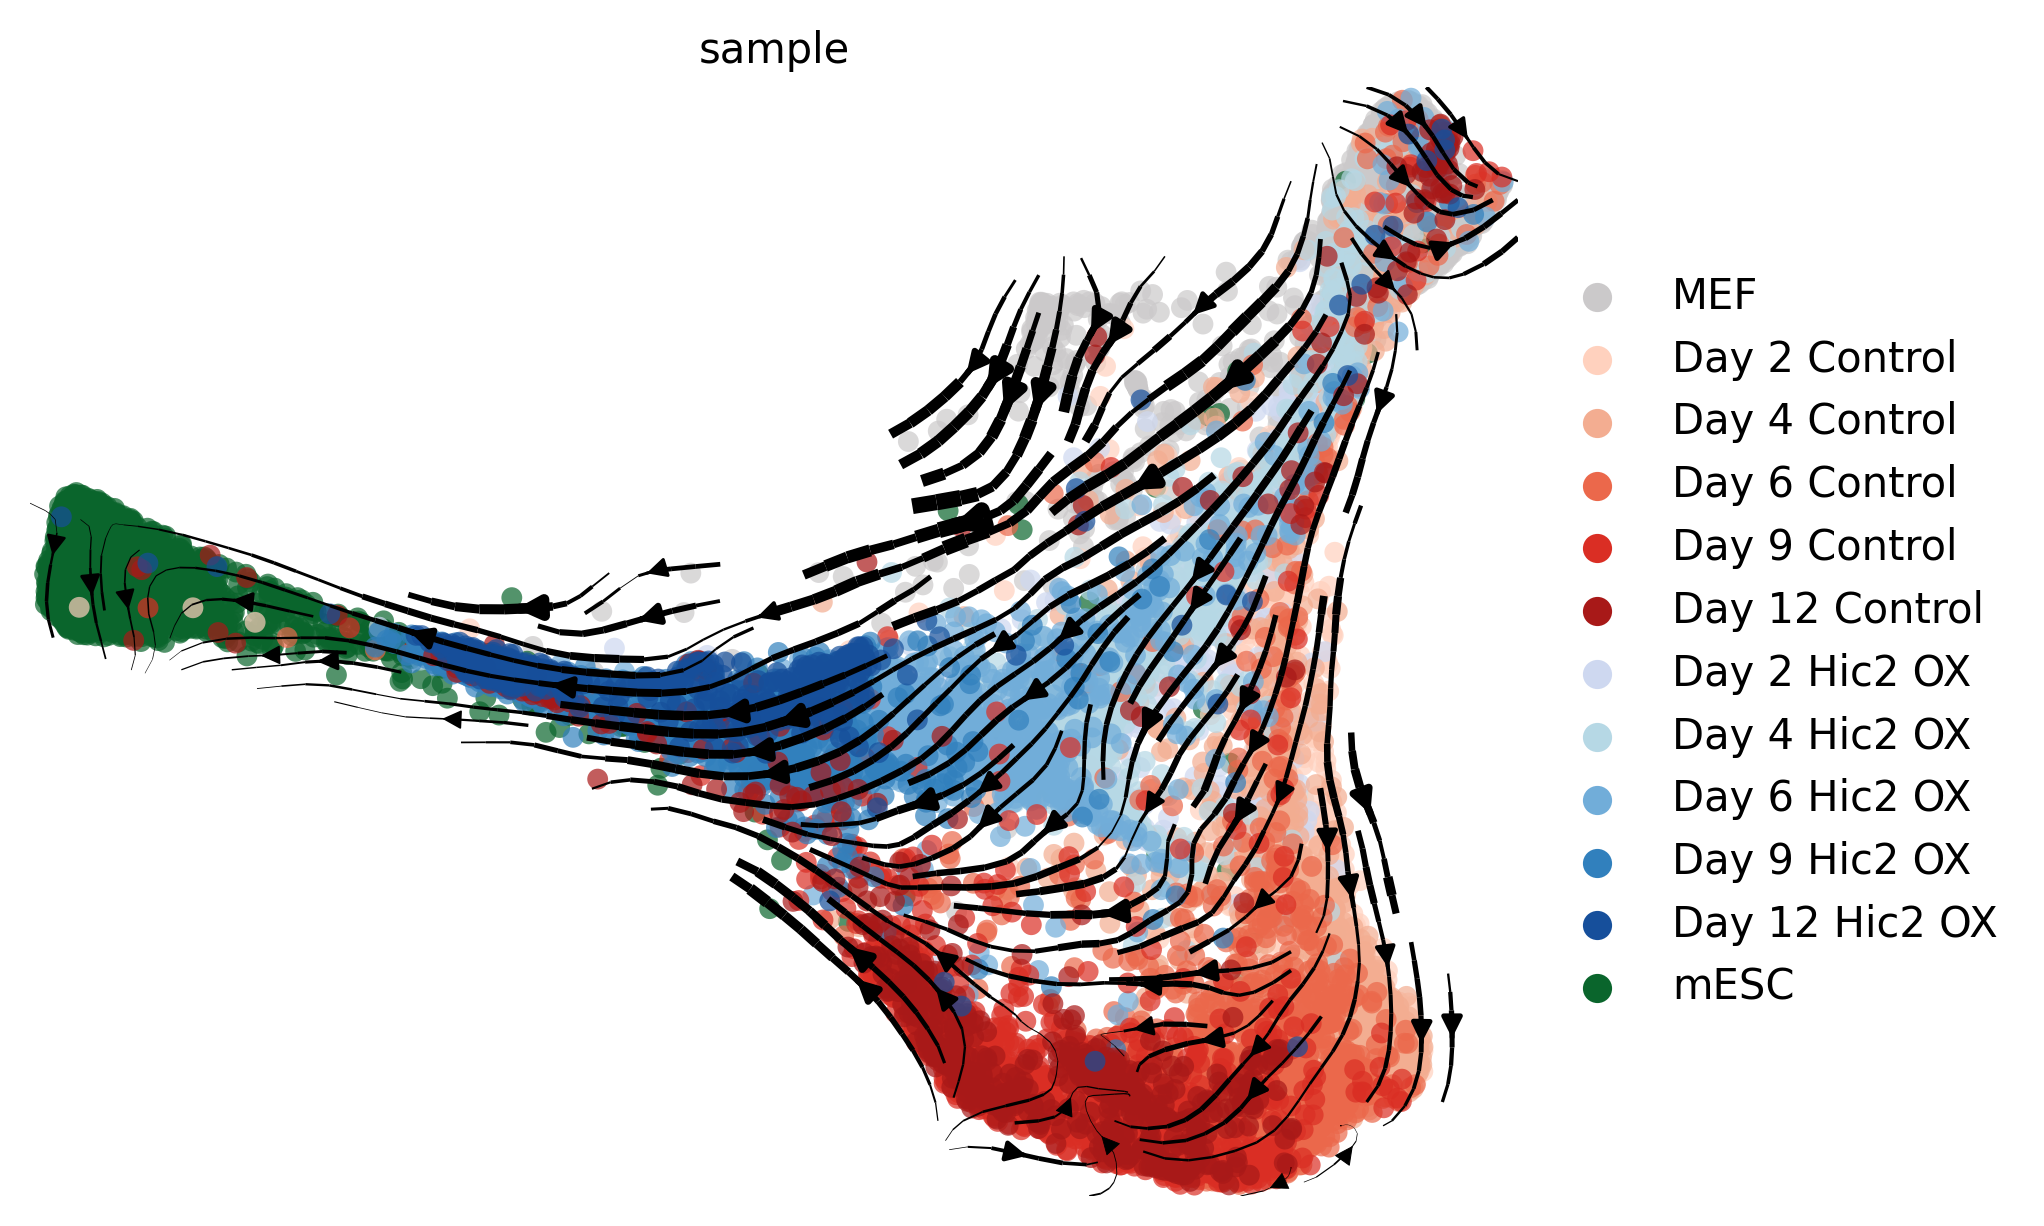

In [21]:
# Plot velocity stream
scvelo.pl.velocity_embedding_stream(adata, density=2,  linewidth=2.0, basis='fdl', dpi=300, s=100, alpha=0.7,
                                 vkey='sde_velocity', color='sample', legend_loc='right margin')

In [22]:
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition'
    var: 'ensemble_ids', 'gene_symbol', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'sample_colors', 'log1p', 'pca', 'neighbors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params'
    obsm: 'X_fdl', 'X_umap', 'X_pca', 'sde_velocity_fdl'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'sde_velocity', 'pred_u', 'pred_s'
    obsp: 'distances', 'connectivities'


In [23]:
# Save adata object
adata.write_h5ad(
    "/scratch/lema/m26_losu/velocity_sdevelo.h5ad",
    compression=hdf5plugin.FILTERS["zstd"]
)